# 1D Hartree-Fock SCF with a Fock MPO

This notebook is a minimal spinless Hartree-Fock example. The interaction is a small long-range density-density kernel `V(i,j)`. The Hartree term uses the density profile, while the Fock/exchange term uses the density matrix MPO through the element-wise MPO product

```text
Fock[i,j] = -V[i,j] rho[i,j]
```


In [2]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS

include("../src/TensorBinding.jl")
using .TensorBinding


## 1. Noninteracting open chain

Keep the system deliberately small so the dense-matrix checks at the end are cheap and readable.


In [3]:
L = 3
N = 2^L
t = 1.0
Nel = div(N, 2)

H0 = TensorBinding.get_Hamiltonian("chain_1d", t; L=L, boundary=:open, scale=4.0)
println(H0)


TBHamiltonian | L=3, N=8, scale=4.0, maxlinkdim=2 | geometry: 8 sites, 1D | no Tn cache


## 2. Long-range interaction MPO

`V_mpo` represents the two-index kernel `V(i,j)`. The onsite part is set to zero so this example focuses on intersite Hartree-Fock exchange.


In [ ]:
V0 = 0.8
screening = 4.0
softening = 0.7

Vfun(i, j) = i == j ? 0.0 : V0 * exp(-abs(i - j) / screening) / sqrt((i - j)^2 + softening^2)

V_mpo = TensorBinding.get_mpo(
    L,
    H0.sites,
    Vfun;
    type=Float64,
    tol=1e-8,
    maxbonddim=80,
)

V_dense = real.(TensorBinding.get_matrix(V_mpo, H0.sites))
heatmap(V_dense;
        aspect_ratio=1,
        title="interaction kernel V(i,j)",
        xlabel="j",
        ylabel="i",
        yflip=true)

## 3. Hartree and Fock builders

The Hartree builder contracts `V` with the diagonal density profile. The Fock builder uses the full density matrix MPO and the Hadamard product.


In [ ]:
hartree_builder = TensorBinding.dense_hartree_builder(
    V_mpo,
    L,
    H0.sites;
    background=0.5,
    maxdim=100,
    cutoff=1e-8,
)

fock_builder = TensorBinding.fock_exchange_builder(
    V_mpo;
    sign=-1,
    maxdim=120,
    cutoff=1e-8,
)

rho0 = TensorBinding.get_mps(
    L,
    H0.sites,
    n -> 0.5 + 0.04 * (-1)^n;
    type=Float64,
    tol=1e-10,
)

rho0_vals = [TensorBinding.eval_mps(rho0, n) for n in 0:N-1]
plot(0:N-1, rho0_vals;
     marker=:circle,
     xlabel="site n",
     ylabel="density",
     title="initial density seed",
     legend=false)

## 4. Hartree-Fock SCF

The first iteration starts from the Hartree field generated by the density seed. Once the first density matrix is computed, the Fock MPO is generated and included in subsequent iterations.


In [7]:
result = TensorBinding.scf_meanfield(
    H0,
    hartree_builder;
    fock_builder=fock_builder,
    initial_density=rho0,
    density_method=:mcweeny,
    Nel=Nel,
    fermi=0.0,
    scale=4.5,
    max_scf_iter=30,
    scf_tol=1e-5,
    mix=0.65,
    maxdim=120,
    cutoff=1e-8,
    purif_maxiter=35,
    purif_tol=1e-6,
    verbose=true,
)

println("converged = ", result.converged)
println("iterations = ", result.iterations)
println("final RMS = ", result.rms_error)


┌ Warning: Calling `inner(x::MPS, A::MPO, y::MPS)` where the site indices of the `MPS`
│ `x` and the `MPS` resulting from contracting `MPO` `A` with `MPS` `y` don't
│ match is deprecated as of ITensors v0.3 and will result in an error in ITensors
│ v0.4. The most common cause of this is something like the following:
│ 
│ ```julia
│ s = siteinds("S=1/2")
│ psi = random_mps(s)
│ H = MPO(s, "Id")
│ inner(psi, H, psi)
│ ```
│ 
│ `psi` has the Index structure `-s-(psi)` and `H` has the Index structure
│ `-s'-(H)-s-`, so the Index structure of would be `(dag(psi)-s- -s'-(H)-s-(psi)`
│  unless the prime levels were fixed. Previously we tried fixing the prime level
│   in situations like this, but we will no longer be doing that going forward.
│ 
│ There are a few ways to fix this. You can simply change:
│ 
│ ```julia
│ inner(psi, H, psi)
│ ```
│ 
│ to:
│ 
│ ```julia
│ inner(psi', H, psi)
│ ```
│ 
│ in which case the Index structure will be `(dag(psi)-s'-(H)-s-(psi)`.
│ 
│ Alternatively, you c

SCF iter=1 rms=0.09115027513809777 particle_err=8.126374337891207e-7
SCF iter=2 rms=0.030625561926996125 particle_err=5.554954674025225e-7
SCF iter=3 rms=0.0018827753783427308 particle_err=2.7633864974063727e-7
SCF iter=4 rms=0.014640327154796545 particle_err=4.1872767697626045e-7
SCF iter=5 rms=0.018790481836222356 particle_err=1.5353064011236484e-6
SCF iter=6 rms=0.018671475320210074 particle_err=6.681473561087614e-7
SCF iter=7 rms=0.017064745395686132 particle_err=4.043594152847163e-7
SCF iter=8 rms=0.0151534893644609 particle_err=5.713625852443727e-7
SCF iter=9 rms=0.013216876791621307 particle_err=5.899614641258211e-7
SCF iter=10 rms=0.011518927677261648 particle_err=1.1129077419624878e-6
SCF iter=11 rms=0.009928201870310785 particle_err=7.843303251320322e-8
SCF iter=12 rms=0.00867129396399527 particle_err=2.432767032267691e-7
SCF iter=13 rms=0.007415593360164149 particle_err=1.0760371651485912e-6
SCF iter=14 rms=0.006388584145999819 particle_err=1.8016335090464963e-8
SCF iter=15 

## 5. Density and convergence


In [ ]:
rho = [TensorBinding.eval_mps(result.density_mps, n) for n in 0:N-1]
hist_iter = [h.iter for h in result.history]
hist_rms = [h.rms_error for h in result.history]
particle_err = [h.particle_error for h in result.history]

p1 = plot(0:N-1, rho;
          marker=:circle,
          xlabel="site n",
          ylabel="density",
          title="self-consistent density",
          legend=false)

p2 = plot(hist_iter, hist_rms;
          yscale=:log10,
          marker=:circle,
          xlabel="SCF iteration",
          ylabel="RMS error",
          title="Hartree-Fock convergence",
          label="RMS")
plot!(p2, hist_iter, particle_err; marker=:diamond, label="particle error")

plot(p1, p2; layout=(2, 1), size=(760, 560))

## 6. Fock Hadamard sanity check

For this small system we can compare the MPO result to the dense formula `-V .* rho_matrix`.


max |Fock_MPO - (-V .* rho)| = 0.00012010735761698664


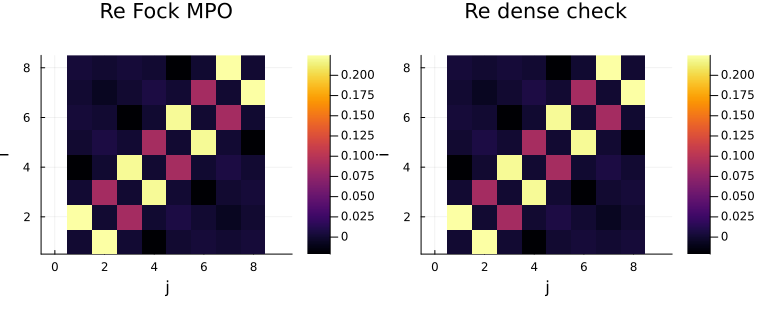

In [9]:
rho_dense = TensorBinding.get_matrix(result.density_mpo, H0.sites)
fock_mpo = result.fock_mpo === nothing ? fock_builder(result.density_mpo, H0.sites) : result.fock_mpo
fock_dense = TensorBinding.get_matrix(fock_mpo, H0.sites)
expected_fock = -V_dense .* rho_dense

println("max |Fock_MPO - (-V .* rho)| = ", maximum(abs.(fock_dense - expected_fock)))

p3 = heatmap(real.(fock_dense);
             aspect_ratio=1,
             colorbar=true,
             title="Re Fock MPO",
             xlabel="j",
             ylabel="i")
p4 = heatmap(real.(expected_fock);
             aspect_ratio=1,
             colorbar=true,
             title="Re dense check",
             xlabel="j",
             ylabel="i")
plot(p3, p4; layout=(1, 2), size=(760, 320))
